In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import torch.optim as optim
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report
from scipy.signal import butter, sosfilt

from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DCASE2024_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2024"

DCASE2024_TRAIN_PATH = DCASE2024_ROOT_PATH / "Train"
DCASE2024_DEV_PATH = DCASE2024_ROOT_PATH / "Dev"
DCASE2024_EVAL_PATH = DCASE2024_ROOT_PATH / "Eval"

DCASE2022_ROOT_PATH = Path.cwd().parent / "data/raw/dcase-2022"

DCASE2022_TRAIN_PATH = DCASE2022_ROOT_PATH / "Train"
DCASE2022_DEV_PATH = DCASE2022_ROOT_PATH / "Dev"

# ===============================================================
# ===============================================================

SAMPLE_RATE = 16_000
MEL_SPECTROGRAM_PARAMS = {
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 128,
    "window": "hann",
    "center": True,
    "pad_mode": "reflect",
    "power": 2.0,
}

MFCC_PARAMS = {
    "n_mfcc": 128,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 128,
    "dct_type": 2,
    "norm": "ortho",
    "lifter": 0,
}

device

device(type='cuda')

In [3]:
import librosa
import numpy as np


def get_mel_spectrogram(signal, params):
    mel = librosa.feature.melspectrogram(y=signal, **params)
    log_mel = librosa.power_to_db(mel, ref=np.max) 
    return log_mel.astype(np.float32)


def get_mfcc(signal, params):
    mfcc = librosa.feature.mfcc(y=signal, **params)

    return mfcc.astype(np.float32)

In [4]:
def load_audio(audio):
    signal, sample_rate = librosa.load(audio, mono=True, sr=SAMPLE_RATE)

    return signal, sample_rate

def pad_or_trim(signal, target_len):
    if len(signal) > target_len:
        return signal[:target_len]
    elif len(signal) < target_len:
        return np.pad(signal, (0, target_len - len(signal)), 'constant')

    return signal

def rms_normalize(signal, target_rms=0.1, eps=1e-8):
    rms = np.sqrt(np.mean(signal**2) + eps)
    gain = target_rms / (rms + eps)

    return (signal * gain).astype(np.float32)

def peak_normalize(signal):
    peak = np.max(np.abs(signal))
    if peak > 0:
        return signal / peak
    return signal


def preprocess_data(signals, padding_or_trim=True, denoise_method=None, normalize_method=None):
    mel_features = []
    mfcc_features = []
    target_len = 10 * SAMPLE_RATE

    for signal in signals:
        if padding_or_trim:
            signal = pad_or_trim(signal, target_len)
        if denoise_method:
            signal = denoise_method(signal)
        if normalize_method:
            signal = normalize_method(signal)

        mel = get_mel_spectrogram(signal, MEL_SPECTROGRAM_PARAMS)
        mfcc = get_mfcc(signal, MFCC_PARAMS)

        # norm_mel = min_max_scaler(mel)
        # norm_mfcc = min_max_scaler(mfcc)

        mel_features.append(mel)
        mfcc_features.append(mfcc)

    return mel_features, mfcc_features

def bandpass_filter(signal, sr=16000, low=80, high=7500, order=4):
    nyq = 0.5 * sr
    low_n = low / nyq
    high_n = high / nyq
    sos = butter(order, [low_n, high_n], btype="bandpass", output="sos")
    return sosfilt(sos, signal).astype(np.float32)

def spectral_gate(signal, sr=16000, noise_sec=0.25):
    n = int(noise_sec * sr)
    noise_clip = signal[:n]
    return nr.reduce_noise(y=signal, y_noise=noise_clip, sr=sr).astype(np.float32)

def highpass_filter(signal, sr=16000, cutoff=80, order=4):
    nyq = 0.5 * sr
    cutoff_n = cutoff / nyq
    sos = butter(order, cutoff_n, btype="highpass", output="sos")
    return sosfilt(sos, signal).astype(np.float32)

# Leitura dos áudios


In [5]:
def read_dcase_dev_set(path, ignore_machine_types=None, only_machine_type=None):
    if ignore_machine_types is None:
        ignore_machine_types = []

    X_train, y_train, mtype_train = [], [], []
    X_test, y_test, mtype_test = [], [], []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        mtype = machine_dir.name
        if mtype in ignore_machine_types:
            continue

        if only_machine_type is not None and mtype != only_machine_type:
            continue

        for section in ["train", "test"]:
            data_dir = machine_dir / section
            if not data_dir.exists():
                continue

            wavs = list(data_dir.glob("*.wav"))
            for audio_file in tqdm(wavs, desc=f"{mtype} - {section}"):
                try:
                    signal, _ = load_audio(str(audio_file))

                    if section == "train":
                        label = 0
                        X_train.append(signal)
                        y_train.append(label)
                        mtype_train.append(mtype)

                    else:
                        label = 1 if "anomaly" in audio_file.name.lower() else 0
                        X_test.append(signal)
                        y_test.append(label)
                        mtype_test.append(mtype)

                except Exception as e:
                    print(f"Erro ao processar {audio_file.name}: {e}")

    return X_train, X_test, y_train, y_test, mtype_train, mtype_test


def read_dcase_train_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "train"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo train"):
            if audio_file.suffix != ".wav":
                continue
            try:
                label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y


def read_dcase_eval_set(path):
    X = []
    machine_type = []
    y = []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        data_dir = machine_dir / "test"
        if not data_dir.exists():
            continue

        for audio_file in tqdm(data_dir.iterdir(), desc="Lendo eval"):
            if audio_file.suffix != ".wav":
                continue
            try:
                if "anomaly" in audio_file.name:
                    label = 1
                else:
                    label = 0

                signal, _ = load_audio(audio_file)

                X.append(signal)
                machine_type.append(machine_dir.name)
                y.append(label)

            except Exception as e:
                print(f"Erro ao processar {audio_file.name}: {e}")

    return X, machine_type, y

In [6]:
def read_dcase_dev_set(path, ignore_machine_types=None, only_machine_type=None, only_section=None, ignore_target_domain=True):
    if ignore_machine_types is None:
        ignore_machine_types = []

    X_train, y_train, mtype_train, section_train = [], [], [], []
    X_test, y_test, mtype_test, section_test = [], [], [], []

    for machine_dir in Path(path).iterdir():
        if not machine_dir.is_dir():
            continue

        mtype = machine_dir.name
        if mtype in ignore_machine_types:
            continue

        if only_machine_type is not None and mtype != only_machine_type:
            continue

        for section_folder in ["train", "test"]:
            data_dir = machine_dir / section_folder
            if not data_dir.exists():
                continue

            wavs = list(data_dir.glob("*.wav"))
            for audio_file in tqdm(wavs, desc=f"{mtype} - {section_folder}"):

                # --- NOVA VERIFICAÇÃO: IGNORAR TARGET DOMAIN ---
                if ignore_target_domain and "target" in audio_file.name.lower():
                    continue

                try:
                    # Extrai a seção do nome do arquivo
                    parts = audio_file.name.split('_')
                    if 'section' in parts:
                        idx = parts.index('section')
                        section_id = f"section_{parts[idx+1]}"
                    else:
                        section_id = "unknown"

                    # Se você especificou uma seção e ela for diferente da atual, pula este áudio
                    if only_section is not None and section_id != only_section:
                        continue

                    signal, _ = load_audio(str(audio_file))

                    if section_folder == "train":
                        label = 0
                        X_train.append(signal)
                        y_train.append(label)
                        mtype_train.append(mtype)
                        section_train.append(section_id)

                    else:
                        label = 1 if "anomaly" in audio_file.name.lower() else 0
                        X_test.append(signal)
                        y_test.append(label)
                        mtype_test.append(mtype)
                        section_test.append(section_id)

                except Exception as e:
                    print(f"Erro ao processar {audio_file.name}: {e}")

    return X_train, X_test, y_train, y_test, mtype_train, mtype_test, section_train, section_test

In [19]:
signals_train, signals_test, labels_train, labels_test, mtype_train, mtype_test, sec_train, sec_test = read_dcase_dev_set(
    DCASE2022_DEV_PATH,
    only_machine_type='fan',
    only_section='section_00'
)
print()
print('=' * 45)
print('Leitura Concluída!')
print(f'Total de amostras: {len(signals_train) + len(signals_test)}')
print(f'Amostras de treino: {len(signals_train)}')
print(f'Amostras de testes: {len(signals_test)}')
print(f'Máquinas de treino: {np.unique(mtype_train)}')
print(f'Máquinas de teste: {np.unique(mtype_test)}')
print('=' * 45)
print()

fan - train:   0%|          | 0/3000 [00:00<?, ?it/s]

fan - test: 100%|██████████| 600/600 [00:00<00:00, 12057.45it/s]


Leitura Concluída!
Total de amostras: 1090
Amostras de treino: 990
Amostras de testes: 100
Máquinas de treino: ['fan']
Máquinas de teste: ['fan']



In [20]:
class MachineAudioDataset(Dataset):
    def __init__(self, features, labels):
       self.features = features
       self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]

        return (torch.tensor(feature, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))

In [21]:
def to_time_major(feat_ct: np.ndarray) -> np.ndarray:
    return feat_ct.T.astype(np.float32)

def fit_zscore(train_feats_tc: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    all_frames = np.concatenate(train_feats_tc, axis=0)  # (sum_T, C)
    mean = all_frames.mean(axis=0).astype(np.float32)
    std = (all_frames.std(axis=0) + 1e-8).astype(np.float32)
    return mean, std

def apply_zscore(feats_tc: list[np.ndarray], mean: np.ndarray, std: np.ndarray) -> list[np.ndarray]:
    out = []
    for x in feats_tc:
        out.append(((x - mean) / std).astype(np.float32))
    return out

In [22]:
import torch
import torch.nn as nn

class GRUAutoencoder(nn.Module):
    def __init__(self, input_size=128, hidden_dim=64):
        # input_size=128 para bater com as 128 dimensões do MFCC usadas no dataset
        super(GRUAutoencoder, self).__init__()

        self.drop = nn.Dropout(0.1)

        # ==========================================
        # ENCODER (Comprime a informação)
        # ==========================================
        # Reduzimos a dimensionalidade para forçar a rede a aprender os padrões principais
        self.enc_gru1 = nn.GRU(input_size, hidden_dim, batch_first=True)
        self.enc_gru2 = nn.GRU(hidden_dim, hidden_dim // 2, batch_first=True)

        # ==========================================
        # DECODER (Reconstrói a informação)
        # ==========================================
        # Faz o caminho inverso, tentando expandir a compressão de volta ao original
        self.dec_gru1 = nn.GRU(hidden_dim // 2, hidden_dim, batch_first=True)
        self.dec_gru2 = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        # Camada densa aplicada a cada timestep para reconstruir os 128 valores exatos
        self.reconstructor = nn.Linear(hidden_dim, input_size)

    def forward(self, x):
        # Shape esperado de x: (batch_size, sequence_length, input_size)

        # --- Fluxo do Encoder ---
        enc_out, _ = self.enc_gru1(x)
        enc_out = self.drop(enc_out)

        # O enc_out_final (hidden_dim // 2) é o nosso "Bottleneck"
        enc_out_final, _ = self.enc_gru2(enc_out)

        # --- Fluxo do Decoder ---
        dec_out, _ = self.dec_gru1(enc_out_final)
        dec_out = self.drop(dec_out)

        dec_out_final, _ = self.dec_gru2(dec_out)

        # --- Reconstrução Final ---
        # Retorna um tensor exatamente do mesmo tamanho que o tensor 'x' da entrada
        reconstructed = self.reconstructor(dec_out_final)

        return reconstructed

In [23]:
train_mel, train_mfcc = preprocess_data(signals_train, denoise_method=None, normalize_method=None)
test_mel,  test_mfcc  = preprocess_data(signals_test,  denoise_method=None, normalize_method=None)

train_mel  = [to_time_major(m) for m in train_mel]
test_mel   = [to_time_major(m) for m in test_mel]

train_mfcc = [to_time_major(m) for m in train_mfcc]
test_mfcc  = [to_time_major(m) for m in test_mfcc]

# ---> APLICANDO Z-SCORE NO MEL-ESPECTROGRAMA <---
mean_mel, std_mel = fit_zscore(train_mel)
train_mel = apply_zscore(train_mel, mean_mel, std_mel)
test_mel  = apply_zscore(test_mel,  mean_mel, std_mel)

# Aplicando Z-score no MFCC (caso queira comparar depois)
mean_mfcc, std_mfcc = fit_zscore(train_mfcc)
train_mfcc = apply_zscore(train_mfcc, mean_mfcc, std_mfcc)
test_mfcc  = apply_zscore(test_mfcc,  mean_mfcc, std_mfcc)

train_mel  = torch.tensor(train_mel,  dtype=torch.float32)
train_mfcc = torch.tensor(train_mfcc, dtype=torch.float32)
test_mel   = torch.tensor(test_mel,   dtype=torch.float32)
test_mfcc  = torch.tensor(test_mfcc,  dtype=torch.float32)

In [24]:
features_set = "mel"

if features_set == "mel":
    train_features = train_mel
    test_features = test_mel
elif features_set == "mfcc":
    train_features = train_mfcc
    test_features = test_mfcc
elif features_set == "combine":
    train_features = torch.cat([train_mel, train_mfcc], dim=2)
    test_features  = torch.cat([test_mel,  test_mfcc],  dim=2)
else:
    raise ValueError("features_set inválido")

input_size = train_features.shape[2]

train_dataset = MachineAudioDataset(train_features, labels_train)
test_dataset  = MachineAudioDataset(test_features,  labels_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

lr = 0.003
epochs = 100

model = GRUAutoencoder(input_size=input_size, hidden_dim=64).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [25]:
print("Iniciando o Treinamento do Autoencoder GRU...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    # O DataLoader retorna (features, labels), mas nós ignoramos as labels (_)
    for batch_features, _ in train_loader:
        batch_features = batch_features.to(device)

        # 1. Forward Pass: O modelo tenta reconstruir o próprio áudio
        reconstructed = model(batch_features)

        # 2. Calcula a Perda (MSE) entre a entrada original e a reconstrução
        loss = criterion(reconstructed, batch_features)

        # 3. Backward Pass e Otimização
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_features.size(0)

    train_loss /= len(train_loader.dataset)

    print(f'Epoch [{epoch+1}/{epochs}] - MSE Loss (Normal Data): {train_loss:.6f}')

Iniciando o Treinamento do Autoencoder GRU...


C:\Users\josel\AppData\Local\Temp\ipykernel_31232\3065367794.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (torch.tensor(feature, dtype=torch.float32),


Epoch [1/100] - MSE Loss (Normal Data): 0.506436
Epoch [2/100] - MSE Loss (Normal Data): 0.338365
Epoch [3/100] - MSE Loss (Normal Data): 0.318017
Epoch [4/100] - MSE Loss (Normal Data): 0.313076
Epoch [5/100] - MSE Loss (Normal Data): 0.309335
Epoch [6/100] - MSE Loss (Normal Data): 0.307265
Epoch [7/100] - MSE Loss (Normal Data): 0.301570
Epoch [8/100] - MSE Loss (Normal Data): 0.292694
Epoch [9/100] - MSE Loss (Normal Data): 0.284174
Epoch [10/100] - MSE Loss (Normal Data): 0.275322
Epoch [11/100] - MSE Loss (Normal Data): 0.266205
Epoch [12/100] - MSE Loss (Normal Data): 0.259666
Epoch [13/100] - MSE Loss (Normal Data): 0.254757
Epoch [14/100] - MSE Loss (Normal Data): 0.245707
Epoch [15/100] - MSE Loss (Normal Data): 0.238227
Epoch [16/100] - MSE Loss (Normal Data): 0.231143
Epoch [17/100] - MSE Loss (Normal Data): 0.227228
Epoch [18/100] - MSE Loss (Normal Data): 0.223460
Epoch [19/100] - MSE Loss (Normal Data): 0.218186
Epoch [20/100] - MSE Loss (Normal Data): 0.212181
Epoch [21

In [26]:
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

print("\nIniciando a Avaliação (Inferência)...")

model.eval()
anomaly_scores = []
true_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)

        # 1. Reconstrói os dados
        reconstructed = model(batch_features)

        # 2. Calcula o erro (MSE) por FRAME (média apenas na dimensão das features, dim=2)
        # O shape passa de (batch, frames, features) para (batch, frames)
        mse_per_frame = torch.mean((reconstructed - batch_features) ** 2, dim=2)

        # 3. O Pulo do Gato: Selecionar os 30 piores frames (~1 segundo de áudio)
        # Isto impede a diluição de anomalias curtas
        topk_mse, _ = torch.topk(mse_per_frame, k=30, dim=1)

        # 4. O score da amostra é a média apenas destes piores frames
        mse_per_sample = torch.mean(topk_mse, dim=1)

        anomaly_scores.extend(mse_per_sample.cpu().numpy())
        true_labels.extend(batch_labels.numpy())

auc = roc_auc_score(true_labels, anomaly_scores)
print(f"ROC-AUC do Autoencoder GRU (com Top-K): {auc:.2%}")


Iniciando a Avaliação (Inferência)...
ROC-AUC do Autoencoder GRU (com Top-K): 68.68%


C:\Users\josel\AppData\Local\Temp\ipykernel_31232\3065367794.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (torch.tensor(feature, dtype=torch.float32),


Limiar calculado (Percentil 95 dos normais): 0.257313

--- Relatório de Classificação ---
              precision    recall  f1-score   support

  Normal (0)       0.60      0.94      0.73        50
Anomalia (1)       0.86      0.38      0.53        50

    accuracy                           0.66       100
   macro avg       0.73      0.66      0.63       100
weighted avg       0.73      0.66      0.63       100



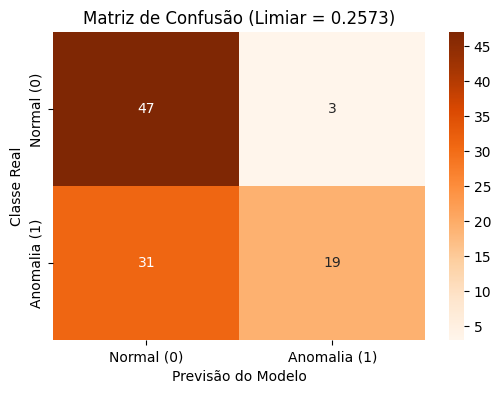

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

anomaly_scores = np.array(anomaly_scores)
true_labels = np.array(true_labels)

# ==========================================
# 1. Definir o Limiar de forma Científica
# ==========================================
# Vamos olhar APENAS para os erros dos áudios normais
mse_normais = anomaly_scores[true_labels == 0]

# Definimos o limiar de corte no percentil 95 (confiança de 95% na normalidade)
limiar_cientifico = np.percentile(mse_normais, 95)

print(f"Limiar calculado (Percentil 95 dos normais): {limiar_cientifico:.6f}")

# ==========================================
# 2. Gerar previsões
# ==========================================
final_predictions = (anomaly_scores >= limiar_cientifico).astype(int)

# ==========================================
# 3. Relatório e Matriz de Confusão
# ==========================================
print("\n--- Relatório de Classificação ---")
print(classification_report(true_labels, final_predictions, target_names=["Normal (0)", "Anomalia (1)"]))

cm = confusion_matrix(true_labels, final_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Normal (0)", "Anomalia (1)"],
            yticklabels=["Normal (0)", "Anomalia (1)"])

plt.ylabel("Classe Real")
plt.xlabel("Previsão do Modelo")
plt.title(f"Matriz de Confusão (Limiar = {limiar_cientifico:.4f})")
plt.show()